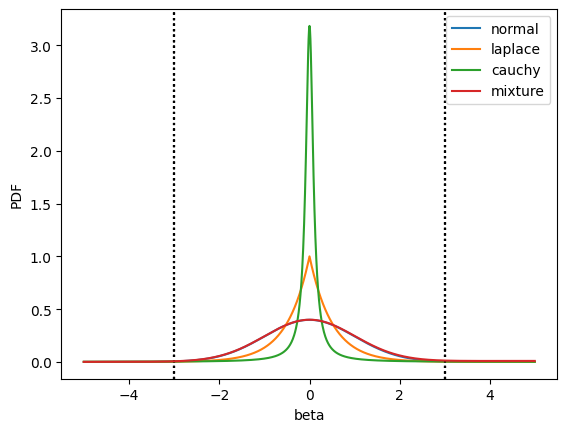

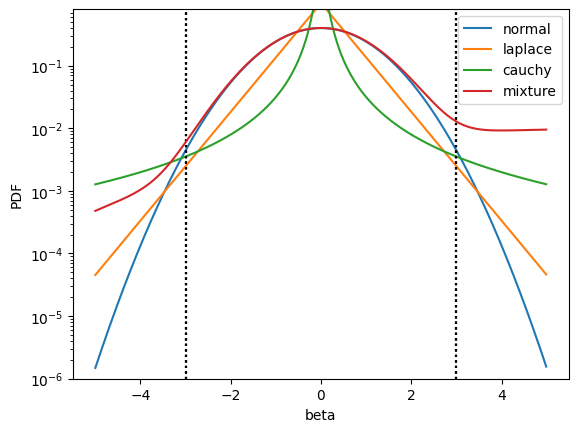

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, cauchy, laplace

# prior_type = "mixture"
# prior_type = "cauchy"
# prior_type = "laplace"
prior_type = "normal"

betas = np.arange(-5, 5, 0.01)
tau = 1
alpha = 1e-2
sigma_1 = 3
lfc = np.log(0.5)  # 50% downreg


priors = {
    "normal": norm.pdf(betas, scale=tau),
    "laplace": laplace.pdf(betas, scale=tau / 2),
    "cauchy": cauchy.pdf(betas, scale=tau / 10),
    "mixture": alpha * norm.cdf(betas, scale=sigma_1) + (1 - alpha) * norm.pdf(betas, scale=tau),
}

for prior_type, prior in priors.items():
    plt.axvline(tau * 3, linestyle="dotted", color="black")
    plt.axvline(-tau * 3, linestyle="dotted", color="black")
    plt.plot(betas, prior, label=prior_type)
    plt.xlabel("beta")
    plt.ylabel("PDF")
    # plt.ylim(1e-6, prior.max() * 10)
    # plt.title("Two-Component Normal Mixture Model PDF")
    # plt.semilogy()
plt.legend()
plt.show()

for prior_type, prior in priors.items():
    plt.axvline(tau * 3, linestyle="dotted", color="black")
    plt.axvline(-tau * 3, linestyle="dotted", color="black")
    plt.plot(betas, prior, label=prior_type)
    plt.xlabel("beta")
    plt.ylabel("PDF")
    # plt.ylim(1e-6, prior.max() * 10)
    # plt.title("Two-Component Normal Mixture Model PDF")
    # plt.semilogy()
plt.legend()
plt.semilogy()
plt.ylim(1e-6, prior.max() * 2)
plt.show()

In [2]:
# import sympy as sp

# # sp.__version__
# from sympy.stats import Cauchy, quantile

from scipy.stats import cauchy

In [3]:
# cauchy.ppf(0.05, scale=0.03)
# norm.ppf(0.05, scale=0.1)

# cauchy.cdf(-0.1, scale=0.03)
# norm.ppf(0.05, scale=0.05)

# gamma = sp.symbols('gamma')
# cauchy = Cauchy("x", 0, gamma)
# qf = quantile(cauchy)(0.05)
# qf
# eq = sp.Eq(quantile, -0.1)
# solution = sp.solve(eq, gamma)
#
# gamma_value = solution[0]
# gamma_value

/Users/ljb80/.virtualenvs/perturbo-dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(array([18.,  2.,  0.,  0.,  0.,  0.,  0.,  0.,  0.]),
 array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.]),
 <BarContainer object of 9 artists>)

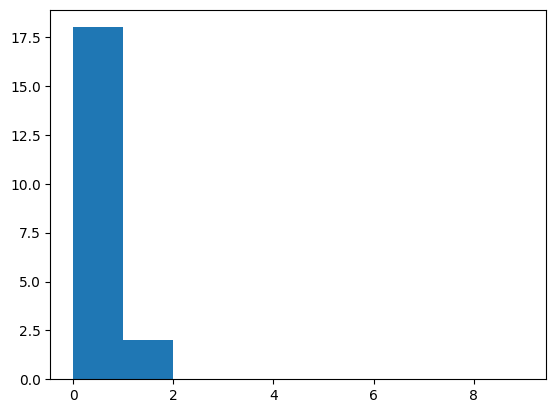

In [4]:
import numpy as np
import numpyro.distributions as dist
import jax.random as random
import numpyro

mean = 0.1
dispersion = 2
n_samples = 20
# lfc = np.log(0.8)  # 20% KD


nb_dist = dist.NegativeBinomial2(mean * np.exp(lfc), dispersion)

samples = nb_dist.sample(random.PRNGKey(0), (n_samples,))
plt.hist(samples, bins=range(10))

$$p(\mathbf x | \theta) = \prod_i p (x_i | \theta)$$
$$\log p(\mathbf x | \theta) = \sum_i \log p (x_i | \theta)$$

$$ p(\theta | x) \propto p(\theta) p(x|\theta) $$


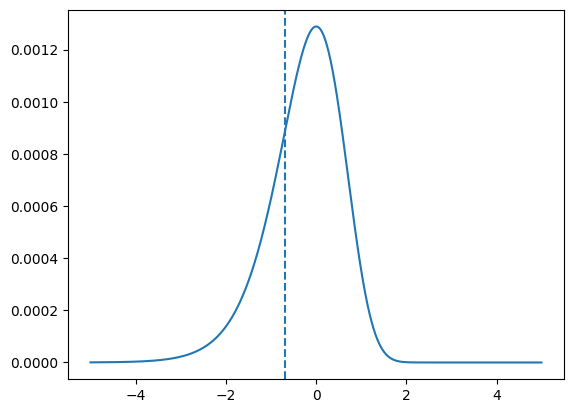

In [5]:
def log_likelihood(beta, samples, mean, dispersion):
    return dist.NegativeBinomial2(mean * np.exp(beta), dispersion).log_prob(samples).sum()


log_likelihoods = np.array([log_likelihood(beta, samples, mean, dispersion) for beta in betas])
plt.plot(betas, np.exp(log_likelihoods))
plt.axvline(lfc, linestyle="dashed")
# plt.semilogy()
plt.show()
# log_likelihoods.shape

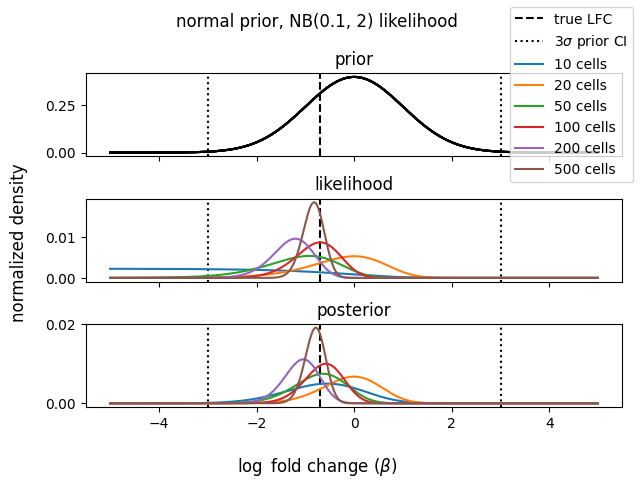

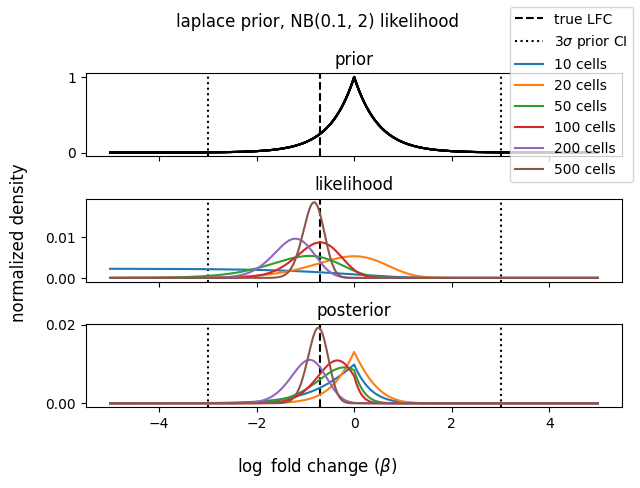

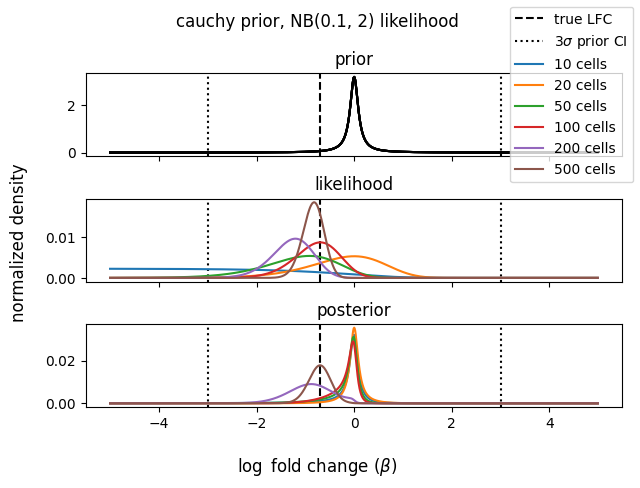

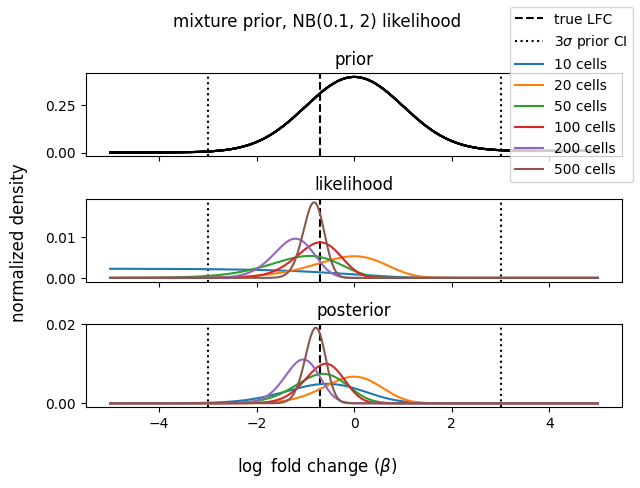

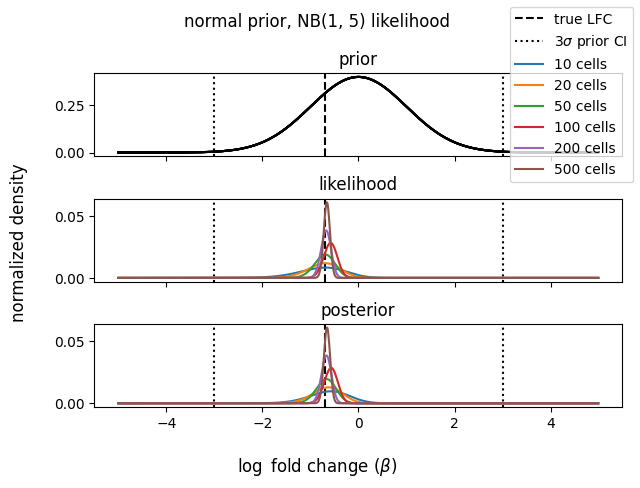

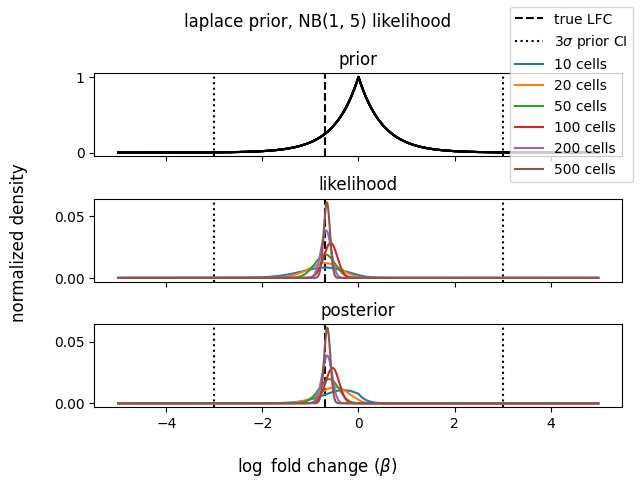

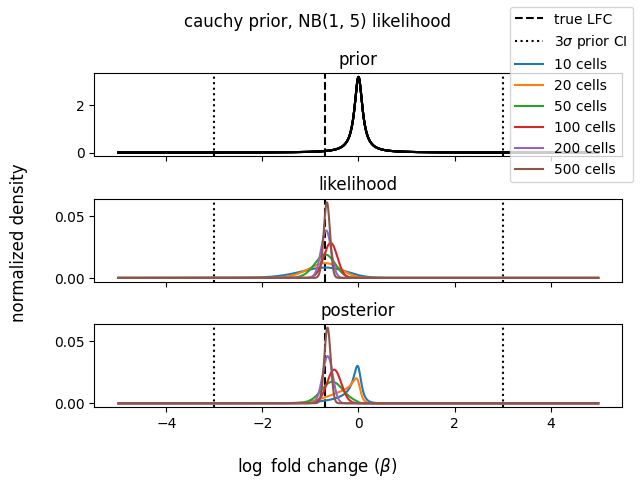

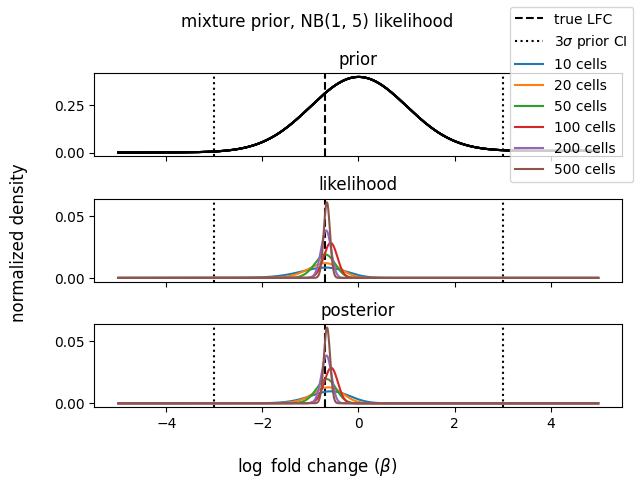

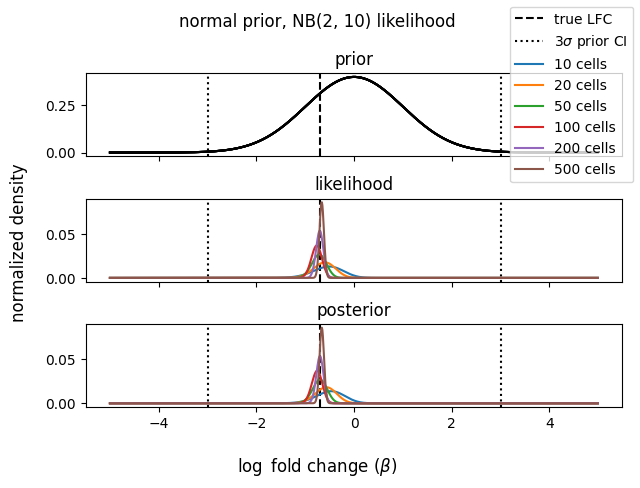

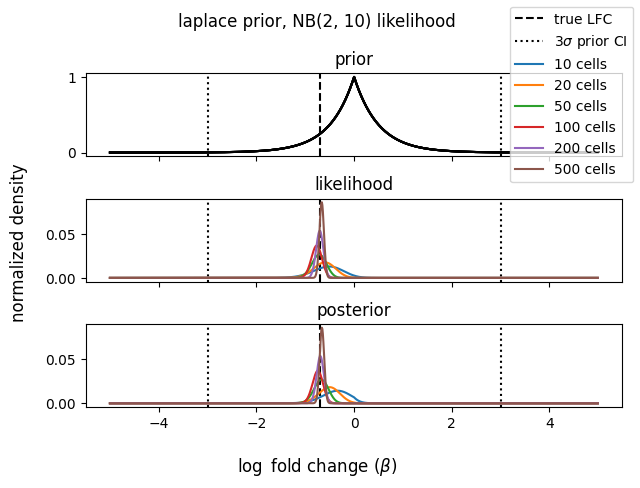

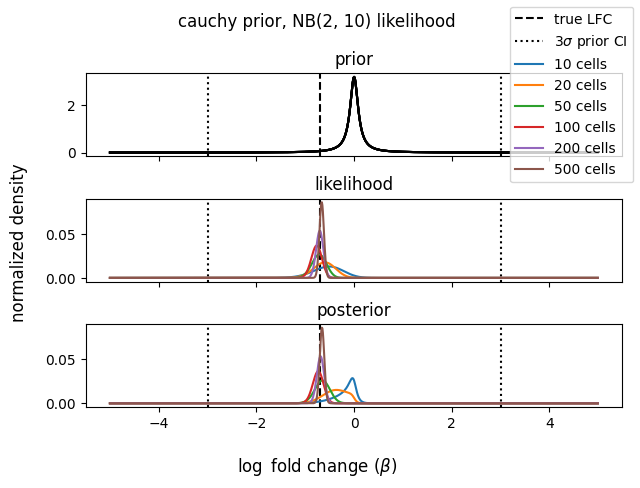

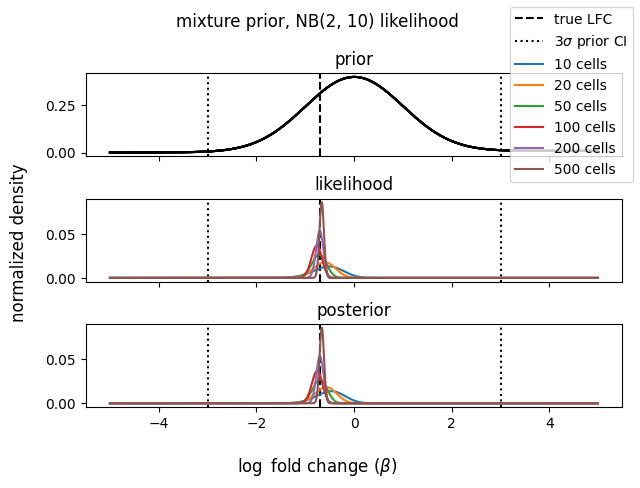

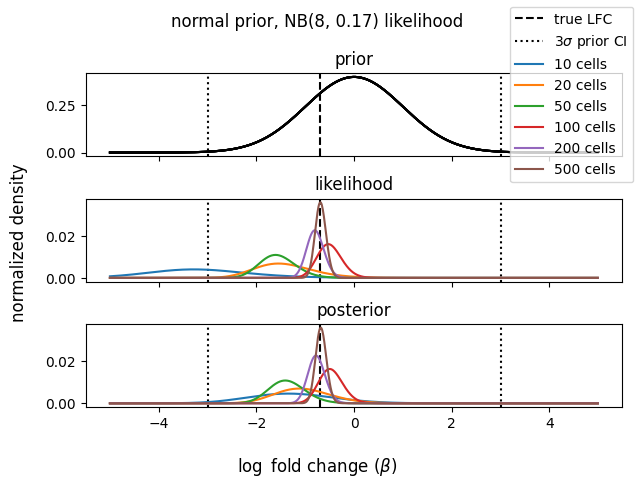

In [6]:
n_sigma = 3
for mean, dispersion in (
    (8, 0.17),
    (0.1, 2),
    (1, 5),
    (2, 10),
):
    for prior_type, prior in priors.items():
        fig, axes = plt.subplots(3, sharex=True)
        ax3, ax1, ax2 = axes
        for i, ax in enumerate(axes):
            ax.axvline(lfc, color="black", linestyle="dashed", label="true LFC" if i == 0 else None)
            ax.axvline(
                tau * n_sigma,
                linestyle="dotted",
                color="black",
                label=f"${n_sigma}\sigma$ prior CI" if i == 0 else None,
            )
            ax.axvline(-tau * n_sigma, linestyle="dotted", color="black")

        for n_samples in [10, 20, 50, 100, 200, 500]:
            # for n_samples in [10, 20, 50, 100]:
            # sample data
            nb_dist = dist.NegativeBinomial2(mean * np.exp(lfc), dispersion)
            samples = nb_dist.sample(random.PRNGKey(0), (n_samples,))

            # compute likelihood w.r.t. beta
            log_likelihoods = np.array([log_likelihood(beta, samples, mean, dispersion) for beta in betas])

            # compute normalized likelihoods for plotting
            log_likelihoods_norm = log_likelihoods - log_likelihoods.max()
            norm_likelihoods = np.exp(log_likelihoods_norm)
            norm_likelihoods /= norm_likelihoods.sum()

            # compute normalized posteriors for plotting
            posteriors = prior * np.exp(log_likelihoods_norm)
            posteriors /= posteriors.sum()

            label = f"{n_samples} cells"
            ax3.plot(betas, prior, color="black")
            ax2.plot(betas, posteriors)
            ax1.plot(betas, norm_likelihoods, label=label)
        ax1.set_title("likelihood")
        ax2.set_title("posterior")
        ax3.set_title("prior")
        fig.suptitle(f"{prior_type} prior, NB({mean}, {dispersion}) likelihood")
        fig.legend()
        fig.supxlabel(r"$\log$ fold change ($\beta$)")
        fig.supylabel("normalized density")
        plt.tight_layout()
        plt.show()